In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [4]:
subgraph_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7
)

In [5]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [6]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [7]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [8]:
parent_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7
)

In [9]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [10]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [11]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

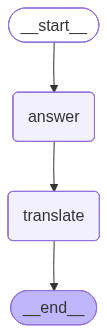

In [12]:
graph = parent_builder.compile()

graph

In [13]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics, also known as quantum mechanics, is a fundamental branch of physics that describes the behavior of matter and energy at the smallest scales: the atomic and subatomic levels.\n\n**In essence, it\'s the science of the very, very small.**\n\nHere\'s a breakdown of what makes it so distinct and fascinating:\n\n1.  **Classical Physics Breaks Down:** Our everyday experience and the rules of "classical physics" (like Isaac Newton\'s laws) work perfectly for large objects. But when you zoom in to the size of atoms and their components (electrons, protons, neutrons, photons), those rules no longer apply. Quantum physics provides a new set of rules for this tiny realm.\n\n2.  **Quantization (The "Quantum" Part):**\n    *   The word "quantum" means a discrete, indivisible unit or packet.\n    *   In quantum physics, many physical properties (like energy, momentum, and angular momentum) aren\'t continuous; they exist only in 